In [46]:
import os

# Use the full path, not the shortened version
os.environ['R_HOME'] = r'C:\Program Files\R\R-4.6.0'
os.environ['PATH'] = (
    r'C:\Program Files\R\R-4.6.0\bin\x64' + ';' +
    r'C:\Program Files\R\R-4.6.0\bin' + ';' +
    os.environ['PATH']
)

# Confirm R is now findable
import subprocess
r_check = subprocess.run(['where', 'R'], capture_output=True, text=True)
print("R found at:", r_check.stdout)
print("R_HOME is now:", os.environ['R_HOME'])

R found at: C:\Program Files\R\R-4.6.0\bin\x64\R.exe
C:\Program Files\R\R-4.6.0\bin\R.exe

R_HOME is now: C:\Program Files\R\R-4.6.0


In [47]:
pip install rpy2

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import Lasso
from sklearn.utils import resample
from sklearn.model_selection import KFold, cross_val_score

In [2]:
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

In [6]:
import sys
import sklearn
import rpy2
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"rpy2 version: {rpy2.__version__}")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
NumPy version: 2.1.3
Pandas version: 2.2.3
Scikit-learn version: 1.6.1


AttributeError: module 'rpy2' has no attribute '__version__'

## Prepare the data before conducting the analysis on the four factors

In [26]:
##read the data in:
SQuIQ_data=pd.read_csv("SQuIQ_forPython.csv")

In [27]:
##Select the continuous variables 
continuous_vars=['SCIBI_ASSCONT','SCIBI_FRIEND', 'SCIBI_NEGBEH', 'SCIBI_SUPPSEE',
                 'D_QEL_EmoCOn','D.QEL_SurfACt','D.QEL_DeepAct','D.QEL_SurfHid',
                 'COMMIT_SelfEff_BuildingCloseness','COMMIT_SelfEff_ReflectiveFunctioning', 
                 'COLLSUP_Total', 'SUPSUPP_Total',
                 'WORKLOAD_Total',
                'Staff_WorkExperience_Years','Ratio_ClientsPerStaff']

##select the dummies:
dummy=['Client_LevelComm_Level2', 'Client_LevelComm_Level3',
       'Client_Level.ID_level2']

In [28]:
##standardized the continuous variables:
scaler=StandardScaler()
SQuIQ_data_scaled=SQuIQ_data.copy()
SQuIQ_data_scaled[continuous_vars]=scaler.fit_transform(SQuIQ_data[continuous_vars])

In [29]:
## view the data
SQuIQ_data_scaled.head()

,ID,SCIBI_ASSCONT,SCIBI_FRIEND,SCIBI_NEGBEH,SCIBI_SUPPSEE,D_QEL_EmoCOn,D.QEL_DeepAct,D.QEL_SurfACt,D.QEL_SurfHid,COMMIT_SelfEff_BuildingCloseness,...,Client_Level.ID_Cat,Staff_WorkExperience_Years,Ratio_ClientsPerStaff,CoRegulation,SensitiveResponsivity,AffectiveConnect,ContactStability,Client_LevelComm_Level2,Client_LevelComm_Level3,Client_Level.ID_level2
0,R_0B1wGINiaSLgM2l,0.597757,0.581214,1.891903,0.643082,-0.414513,0.155657,1.480370,-0.333421,-1.723869,...,1,2.671566,0.892525,0.520699,0.478188,-0.284768,0.394285,0,1,0
1,R_1cTbsmT2x7nPKP2,-0.841503,0.581214,-0.430829,-0.088498,-0.414513,1.471665,-0.380095,1.683372,-0.062524,...,1,-0.120825,0.557490,0.320498,0.629445,0.377411,0.174661,0,1,0
2,R_1dHnlHhv89dahWA,0.777665,-0.161781,1.311220,-0.820077,-0.414513,-1.599021,-1.620405,-0.837620,-0.141635,...,2,-1.033722,0.222456,-0.125501,0.380713,0.300147,-1.299471,1,0,1
3,R_1DUSkRz3tAdNlHP,0.957572,-0.161781,1.020879,1.008872,-0.414513,0.594326,0.550138,-0.333421,1.203263,...,1,1.490170,-0.112579,0.265949,-0.207281,0.430654,0.394285,1,0,0
4,R_1gG866USNIBBPkz,0.237942,0.581214,0.149854,-0.454287,-0.414513,-0.283013,-0.070018,-0.333421,-1.407423,...,2,-0.657823,0.557490,-0.409739,0.087931,0.485391,0.945915,0,0,1


In [30]:
SQuIQ_data_scaled.isna().sum()

ID                                      0
SCIBI_ASSCONT                           0
SCIBI_FRIEND                            0
SCIBI_NEGBEH                            0
SCIBI_SUPPSEE                           0
D_QEL_EmoCOn                            0
D.QEL_DeepAct                           0
D.QEL_SurfACt                           0
D.QEL_SurfHid                           0
COMMIT_SelfEff_BuildingCloseness        0
COMMIT_SelfEff_ReflectiveFunctioning    0
COLLSUP_Total                           0
SUPSUPP_Total                           0
WORKLOAD_Total                          0
Client_LevelComm_Cat                    0
Client_Level.ID_Cat                     0
Staff_WorkExperience_Years              0
Ratio_ClientsPerStaff                   0
CoRegulation                            0
SensitiveResponsivity                   0
AffectiveConnect                        0
ContactStability                        0
Client_LevelComm_Level2                 0
Client_LevelComm_Level3           

# CoRegulation

## Step 1: Leave-one-out Cross-Validation (LOOCV) to determine the best lambda for lasso regularization 

In [31]:
##define the features and outcome
X=SQuIQ_data_scaled[continuous_vars+dummy].values
Y=SQuIQ_data_scaled['CoRegulation'].values

In [32]:
# Define a range of lambdas to evaluate: 200 values with equal gaps between 10^(-4) to 10^2
lambdas = 10**np.linspace(2, -4, 200)

##conduct LOOCV
loo=LeaveOneOut()
lasso_cv=LassoCV(alphas=lambdas, cv=loo, random_state=24, max_iter=10000)
lasso_cv.fit(X, Y)

LassoCV(alphas=array([1.00000000e+02, 9.32930403e+01, 8.70359136e+01, 8.11984499e+01,
       7.57525026e+01, 7.06718127e+01, 6.59318827e+01, 6.15098579e+01,
       5.73844165e+01, 5.35356668e+01, 4.99450512e+01, 4.65952567e+01,
       4.34701316e+01, 4.05546074e+01, 3.78346262e+01, 3.52970730e+01,
       3.29297126e+01, 3.07211300e+01, 2.86606762e+01, 2.67384162e+01,
       2.49450814e+01, 2.32720248e+0...
       3.73993730e-04, 3.48910121e-04, 3.25508860e-04, 3.03677112e-04,
       2.83309610e-04, 2.64308149e-04, 2.46581108e-04, 2.30043012e-04,
       2.14614120e-04, 2.00220037e-04, 1.86791360e-04, 1.74263339e-04,
       1.62575567e-04, 1.51671689e-04, 1.41499130e-04, 1.32008840e-04,
       1.23155060e-04, 1.14895100e-04, 1.07189132e-04, 1.00000000e-04]),
        cv=LeaveOneOut(), max_iter=10000, random_state=24)

In [33]:
##Extract the MSE for each lambda
MSE_mean_byLambda=np.mean(lasso_cv.mse_path_, axis=1)
MSE_std_byLambda=np.std(lasso_cv.mse_path_, axis=1)

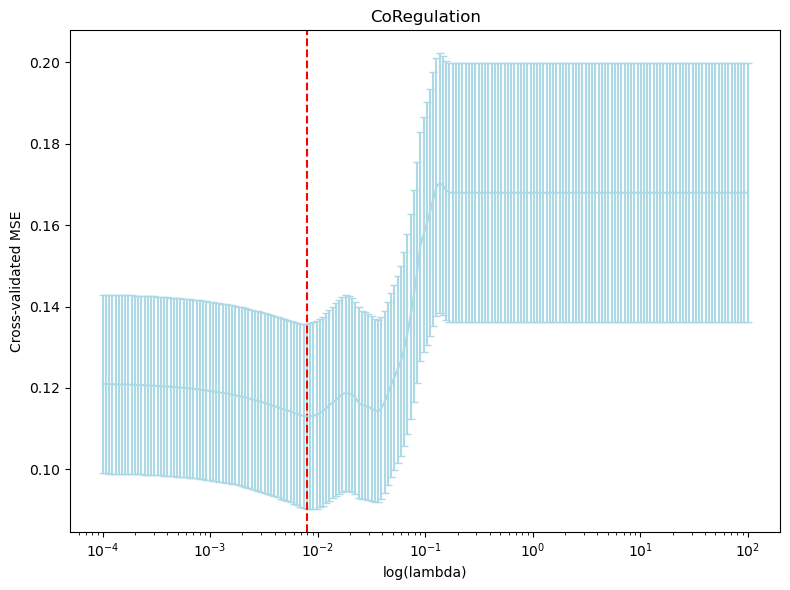

In [34]:
##make the plot to visualize the the lambda correponding to the lowest MSE

#set the canvas
fig, ax=plt.subplots(figsize=(8,6))

#specify the basic for x-axis, y-axis and how to calculate the error bars
ax.errorbar(lasso_cv.alphas_, MSE_mean_byLambda,
           yerr=MSE_std_byLambda/np.sqrt(62),
           color="lightblue", ecolor="lightblue",
           elinewidth=1.5, capsize=3)

#mark the best lambda
ax.axvline(lasso_cv.alpha_, color="red", linestyle="--")

##set the x-axis in log scale
ax.set_xscale('log')

##add label to make the plot more clear
ax.set_xlabel('log(lambda)')
ax.set_ylabel('Cross-validated MSE')
ax.set_title('CoRegulation')

plt.tight_layout()
plt.show()

In [35]:
print("Best Lambda:", lasso_cv.alpha_)

Best Lambda: 0.007934096665797492


## Step 2: fit the lasso regression with the best lambda

In [36]:
##fit the lasso regression
lasso_best=Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X, Y)

Lasso(alpha=np.float64(0.007934096665797492), max_iter=10000)

In [37]:
##Extract coefficient 
CoRegulation_coef_df=pd.DataFrame(
    {'variables': continuous_vars+dummy,
    'Coefficient': lasso_best.coef_}
)

In [38]:
print(CoRegulation_coef_df)

                               variables  Coefficient
0                          SCIBI_ASSCONT    -0.044573
1                           SCIBI_FRIEND     0.092833
2                           SCIBI_NEGBEH     0.145777
3                          SCIBI_SUPPSEE     0.016438
4                           D_QEL_EmoCOn    -0.000000
5                          D.QEL_SurfACt    -0.058015
6                          D.QEL_DeepAct     0.000000
7                          D.QEL_SurfHid    -0.002450
8       COMMIT_SelfEff_BuildingCloseness     0.012327
9   COMMIT_SelfEff_ReflectiveFunctioning     0.018784
10                         COLLSUP_Total     0.000000
11                         SUPSUPP_Total    -0.000000
12                        WORKLOAD_Total     0.035568
13            Staff_WorkExperience_Years     0.010875
14                 Ratio_ClientsPerStaff     0.031051
15               Client_LevelComm_Level2     0.196618
16               Client_LevelComm_Level3     0.418041
17                Client_Lev

## Step 3.1: Use bootstrapping to do robustness check

In [52]:
# Bootstrap settings
n_bootstraps = 1000  
selection_counts = np.zeros(len(continuous_vars + dummy))

# Run bootstrap
for i in range(n_bootstraps):
    # Resample the data with replacement
    X_boot, Y_boot = resample(X, Y, random_state=i)
    
    # Fit LASSO with the best lambda found earlier
    lasso_boot = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    lasso_boot.fit(X_boot, Y_boot)
    
    # Count how many times each predictor has a non-zero coefficient
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# Calculate selection frequency as a percentage
selection_freq = selection_counts / n_bootstraps * 100

# Create results dataframe
CoRegulation_bootstrap_df = pd.DataFrame({
    'Variable': continuous_vars + dummy,
    'Selection_Frequency(%)': selection_freq
})


In [53]:
print(CoRegulation_bootstrap_df)

                                Variable  Selection_Frequency(%)
0                          SCIBI_ASSCONT                    77.2
1                           SCIBI_FRIEND                    96.3
2                           SCIBI_NEGBEH                    99.7
3                          SCIBI_SUPPSEE                    74.2
4                           D_QEL_EmoCOn                    70.4
5                          D.QEL_SurfACt                    86.4
6                          D.QEL_DeepAct                    57.1
7                          D.QEL_SurfHid                    73.1
8       COMMIT_SelfEff_BuildingCloseness                    72.6
9   COMMIT_SelfEff_ReflectiveFunctioning                    74.2
10                         COLLSUP_Total                    70.1
11                         SUPSUPP_Total                    69.7
12                        WORKLOAD_Total                    83.3
13            Staff_WorkExperience_Years                    72.7
14                 Ratio_

## Step 3.2: Covariate Test

In [48]:
import rpy2.robjects as ro
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [49]:
##extract what we need for R:
best_lambda = lasso_cv.alpha_
lasso_coef = lasso_best.coef_ 

In [50]:
##input to R:
%R -i X -i Y -i best_lambda -i lasso_coef

In [51]:
%%R

install.packages("Matrix", type="binary", repos="https://cran.r-project.org")

# Install if needed
if (!require("selectiveInference", quietly=TRUE)) {
    install.packages("selectiveInference", repos="https://cran.r-project.org")
}
library(selectiveInference)

# Convert to R matrix/vector format
X_r <- as.matrix(X)
Y_r <- as.vector(Y)
beta_r <- as.vector(lasso_coef)

# Step 4a: Estimate sigma
lasso.sigma <- estimateSigma(X_r, Y_r, intercept=FALSE, standardize=FALSE)
cat("Sigma estimate:", lasso.sigma$sigmahat, "\n")

# Step 4b: Run fixedLassoInf
lasso.inference <- fixedLassoInf(
    X_r, Y_r,
    beta_r,
    best_lambda,
    sigma = lasso.sigma$sigmahat,
    intercept = FALSE
)

print(lasso.inference)

package 'Matrix' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\U0172378\AppData\Local\Temp\RtmpIzYwRB\downloaded_packages
Sigma estimate: 0.3127427 

Call:
fixedLassoInf(x = X_r, y = Y_r, beta = beta_r, lambda = best_lambda, 
    intercept = FALSE, sigma = lasso.sigma$sigmahat)

Standard deviation of noise (specified or estimated) sigma = 0.313

Testing results at lambda = 0.008, with alpha = 0.100

 Var   Coef Z-score P-value LowConfPt UpConfPt LowTailArea UpTailArea
   1 -0.072  -1.230       1     5.857      Inf           0          0
   2  0.099   2.058       0     4.795      Inf           0          0
   3  0.187   3.204       0     5.849      Inf           0          0
   4  0.012   0.225       1      -Inf   -5.457           0          0
   6 -0.078  -1.431       0      -Inf   -5.433           0          0
   8  0.004   0.090       1     4.669      Inf           0          0
   9  0.020   0.365       1      -Inf   -5.350           0   

Installing package into 'C:/Users/U0172378/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)
trying URL 'https://cran.r-project.org/bin/windows/contrib/4.6/Matrix_1.7-5.zip'
Content type 'application/zip' length 5066352 bytes (4.8 MB)
downloaded 4.8 MB

Loaded glmnet 5.0

Attaching package: 'intervals'

The following object is masked from 'package:Matrix':

    expand


Attaching package: 'stats'

The following objects are masked from 'package:Matrix':

    cov2cor, toeplitz, update

In addition: There were 16 warnings (use warnings() to see them)


# Sensitive Responsivity

## Step 1: Leave-one-out Cross-Validation (LOOCV) to determine the best lambda for lasso regularization 

In [55]:
##define the features and outcome
X=SQuIQ_data_scaled[continuous_vars+dummy].values
Y=SQuIQ_data_scaled['SensitiveResponsivity'].values

In [56]:
# Define a range of lambdas to evaluate: 200 values with equal gaps between 10^(-4) to 10^2
lambdas = 10**np.linspace(2, -4, 200)

##conduct LOOCV
loo=LeaveOneOut()
lasso_cv=LassoCV(alphas=lambdas, cv=loo, random_state=24, max_iter=10000)
lasso_cv.fit(X, Y)

LassoCV(alphas=array([1.00000000e+02, 9.32930403e+01, 8.70359136e+01, 8.11984499e+01,
       7.57525026e+01, 7.06718127e+01, 6.59318827e+01, 6.15098579e+01,
       5.73844165e+01, 5.35356668e+01, 4.99450512e+01, 4.65952567e+01,
       4.34701316e+01, 4.05546074e+01, 3.78346262e+01, 3.52970730e+01,
       3.29297126e+01, 3.07211300e+01, 2.86606762e+01, 2.67384162e+01,
       2.49450814e+01, 2.32720248e+0...
       3.73993730e-04, 3.48910121e-04, 3.25508860e-04, 3.03677112e-04,
       2.83309610e-04, 2.64308149e-04, 2.46581108e-04, 2.30043012e-04,
       2.14614120e-04, 2.00220037e-04, 1.86791360e-04, 1.74263339e-04,
       1.62575567e-04, 1.51671689e-04, 1.41499130e-04, 1.32008840e-04,
       1.23155060e-04, 1.14895100e-04, 1.07189132e-04, 1.00000000e-04]),
        cv=LeaveOneOut(), max_iter=10000, random_state=24)

In [57]:
##Extract the MSE for each lambda
MSE_mean_byLambda=np.mean(lasso_cv.mse_path_, axis=1)
MSE_std_byLambda=np.std(lasso_cv.mse_path_, axis=1)

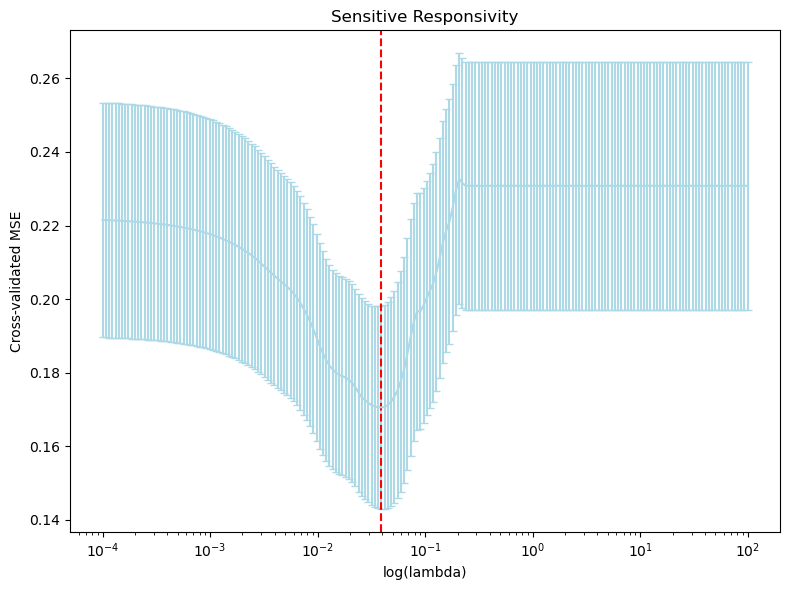

In [58]:
##make the plot to visualize the the lambda correponding to the lowest MSE

#set the canvas
fig, ax=plt.subplots(figsize=(8,6))

#specify the basic for x-axis, y-axis and how to calculate the error bars
ax.errorbar(lasso_cv.alphas_, MSE_mean_byLambda,
           yerr=MSE_std_byLambda/np.sqrt(62),
           color="lightblue", ecolor="lightblue",
           elinewidth=1.5, capsize=3)

#mark the best lambda
ax.axvline(lasso_cv.alpha_, color="red", linestyle="--")

##set the x-axis in log scale
ax.set_xscale('log')

##add label to make the plot more clear
ax.set_xlabel('log(lambda)')
ax.set_ylabel('Cross-validated MSE')
ax.set_title('Sensitive Responsivity')

plt.tight_layout()
plt.show()

In [59]:
print("Best Lambda:", lasso_cv.alpha_)

Best Lambda: 0.039171014908092605


## Step 2: fit the lasso regression with the best lambda

In [60]:
##fit the lasso regression
lasso_best=Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X, Y)

Lasso(alpha=np.float64(0.039171014908092605), max_iter=10000)

In [61]:
##Extract coefficient 
SensitiveResponsivity_coef_df=pd.DataFrame(
    {'variables': continuous_vars+dummy,
    'Coefficient': lasso_best.coef_}
)

In [71]:
print(SensitiveResponsivity_coef_df)

                               variables  Coefficient
0                          SCIBI_ASSCONT     0.000000
1                           SCIBI_FRIEND     0.150434
2                           SCIBI_NEGBEH     0.000000
3                          SCIBI_SUPPSEE    -0.000000
4                           D_QEL_EmoCOn    -0.000000
5                          D.QEL_SurfACt    -0.000000
6                          D.QEL_DeepAct    -0.066471
7                          D.QEL_SurfHid    -0.000000
8       COMMIT_SelfEff_BuildingCloseness     0.078005
9   COMMIT_SelfEff_ReflectiveFunctioning     0.000000
10                         COLLSUP_Total     0.011107
11                         SUPSUPP_Total    -0.000000
12                        WORKLOAD_Total    -0.005838
13            Staff_WorkExperience_Years     0.000000
14                 Ratio_ClientsPerStaff    -0.000000
15               Client_LevelComm_Level2     0.000000
16               Client_LevelComm_Level3     0.000000
17                Client_Lev

## Step 3.1: Use bootstrapping to do robustness check

In [65]:
# Bootstrap settings
n_bootstraps = 1000  
selection_counts = np.zeros(len(continuous_vars + dummy))

# Run bootstrap
for i in range(n_bootstraps):
    # Resample the data with replacement
    X_boot, Y_boot = resample(X, Y, random_state=i)
    
    # Fit LASSO with the best lambda found earlier
    lasso_boot = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    lasso_boot.fit(X_boot, Y_boot)
    
    # Count how many times each predictor has a non-zero coefficient
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# Calculate selection frequency as a percentage
selection_freq = selection_counts / n_bootstraps * 100

# Create results dataframe
SensitiveResponsivity_bootstrap_df = pd.DataFrame({
    'Variable': continuous_vars + dummy,
    'Selection_Frequency(%)': selection_freq
})


In [66]:
print(SensitiveResponsivity_bootstrap_df)

                                Variable  Selection_Frequency(%)
0                          SCIBI_ASSCONT                    36.3
1                           SCIBI_FRIEND                    99.8
2                           SCIBI_NEGBEH                    21.9
3                          SCIBI_SUPPSEE                    17.7
4                           D_QEL_EmoCOn                    25.2
5                          D.QEL_SurfACt                    28.5
6                          D.QEL_DeepAct                    70.8
7                          D.QEL_SurfHid                    36.0
8       COMMIT_SelfEff_BuildingCloseness                    81.1
9   COMMIT_SelfEff_ReflectiveFunctioning                    49.8
10                         COLLSUP_Total                    51.7
11                         SUPSUPP_Total                    32.5
12                        WORKLOAD_Total                    52.9
13            Staff_WorkExperience_Years                    52.3
14                 Ratio_

## Step 3.2: Covariate Test

In [67]:
import rpy2.robjects as ro
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [68]:
##extract what we need for R:
best_lambda = lasso_cv.alpha_
lasso_coef = lasso_best.coef_ 

In [69]:
##input to R:
%R -i X -i Y -i best_lambda -i lasso_coef

In [70]:
%%R

# Install if needed
if (!require("selectiveInference", quietly=TRUE)) {
    install.packages("selectiveInference", repos="https://cran.r-project.org")
}
library(selectiveInference)

# Convert to R matrix/vector format
X_r <- as.matrix(X)
Y_r <- as.vector(Y)
beta_r <- as.vector(lasso_coef)

# Step 4a: Estimate sigma
lasso.sigma <- estimateSigma(X_r, Y_r, intercept=FALSE, standardize=FALSE)
cat("Sigma estimate:", lasso.sigma$sigmahat, "\n")

# Step 4b: Run fixedLassoInf
lasso.inference <- fixedLassoInf(
    X_r, Y_r,
    beta_r,
    best_lambda,
    sigma = lasso.sigma$sigmahat,
    intercept = FALSE
)

print(lasso.inference)

Sigma estimate: 0.3830347 

Call:
fixedLassoInf(x = X_r, y = Y_r, beta = beta_r, lambda = best_lambda, 
    intercept = FALSE, sigma = lasso.sigma$sigmahat)

Standard deviation of noise (specified or estimated) sigma = 0.383

Testing results at lambda = 0.039, with alpha = 0.100

 Var   Coef Z-score P-value LowConfPt UpConfPt LowTailArea UpTailArea
   2  0.186   3.718   0.000     0.103    0.269       0.049      0.049
   7 -0.083  -1.456   0.145    -0.200    0.052       0.050      0.050
   9  0.096   1.863   0.063    -0.009    0.188       0.049      0.050
  11  0.036   0.678   0.501    -0.210    0.119       0.049      0.049
  13 -0.032  -0.577   0.567    -0.115    0.265       0.049      0.050
  18 -0.297  -3.261   0.001    -0.447   -0.144       0.050      0.049

Note: coefficients shown are partial regression coefficients


In addition: Warning message:
In fixedLassoInf(X_r, Y_r, beta_r, best_lambda, sigma = lasso.sigma$sigmahat,  :
  Solution beta does not satisfy the KKT conditions (to within specified tolerances)


# Affective Connectedness

## Step 1: Leave-one-out Cross-Validation (LOOCV) to determine the best lambda for lasso regularization 

In [72]:
##define the features and outcome
X=SQuIQ_data_scaled[continuous_vars+dummy].values
Y=SQuIQ_data_scaled['AffectiveConnect'].values

In [73]:
# Define a range of lambdas to evaluate: 200 values with equal gaps between 10^(-4) to 10^2
lambdas = 10**np.linspace(2, -4, 200)

##conduct LOOCV
loo=LeaveOneOut()
lasso_cv=LassoCV(alphas=lambdas, cv=loo, random_state=24, max_iter=10000)
lasso_cv.fit(X, Y)

LassoCV(alphas=array([1.00000000e+02, 9.32930403e+01, 8.70359136e+01, 8.11984499e+01,
       7.57525026e+01, 7.06718127e+01, 6.59318827e+01, 6.15098579e+01,
       5.73844165e+01, 5.35356668e+01, 4.99450512e+01, 4.65952567e+01,
       4.34701316e+01, 4.05546074e+01, 3.78346262e+01, 3.52970730e+01,
       3.29297126e+01, 3.07211300e+01, 2.86606762e+01, 2.67384162e+01,
       2.49450814e+01, 2.32720248e+0...
       3.73993730e-04, 3.48910121e-04, 3.25508860e-04, 3.03677112e-04,
       2.83309610e-04, 2.64308149e-04, 2.46581108e-04, 2.30043012e-04,
       2.14614120e-04, 2.00220037e-04, 1.86791360e-04, 1.74263339e-04,
       1.62575567e-04, 1.51671689e-04, 1.41499130e-04, 1.32008840e-04,
       1.23155060e-04, 1.14895100e-04, 1.07189132e-04, 1.00000000e-04]),
        cv=LeaveOneOut(), max_iter=10000, random_state=24)

In [74]:
##Extract the MSE for each lambda
MSE_mean_byLambda=np.mean(lasso_cv.mse_path_, axis=1)
MSE_std_byLambda=np.std(lasso_cv.mse_path_, axis=1)

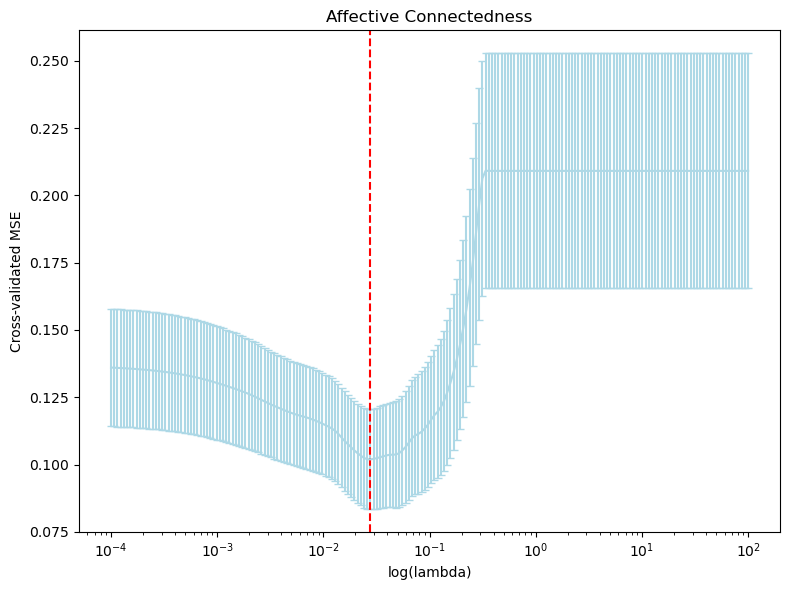

In [75]:
##make the plot to visualize the the lambda correponding to the lowest MSE

#set the canvas
fig, ax=plt.subplots(figsize=(8,6))

#specify the basic for x-axis, y-axis and how to calculate the error bars
ax.errorbar(lasso_cv.alphas_, MSE_mean_byLambda,
           yerr=MSE_std_byLambda/np.sqrt(62),
           color="lightblue", ecolor="lightblue",
           elinewidth=1.5, capsize=3)

#mark the best lambda
ax.axvline(lasso_cv.alpha_, color="red", linestyle="--")

##set the x-axis in log scale
ax.set_xscale('log')

##add label to make the plot more clear
ax.set_xlabel('log(lambda)')
ax.set_ylabel('Cross-validated MSE')
ax.set_title('Affective Connectedness')

plt.tight_layout()
plt.show()

In [76]:
print("Best Lambda:", lasso_cv.alpha_)

Best Lambda: 0.027682866303920667


## Step 2: fit the lasso regression with the best lambda

In [77]:
##fit the lasso regression
lasso_best=Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X, Y)

Lasso(alpha=np.float64(0.027682866303920667), max_iter=10000)

In [78]:
##Extract coefficient 
AffectiveConnect_coef_df=pd.DataFrame(
    {'variables': continuous_vars+dummy,
    'Coefficient': lasso_best.coef_}
)

In [79]:
print(AffectiveConnect_coef_df)

                               variables  Coefficient
0                          SCIBI_ASSCONT    -0.040055
1                           SCIBI_FRIEND     0.272023
2                           SCIBI_NEGBEH     0.000000
3                          SCIBI_SUPPSEE     0.000000
4                           D_QEL_EmoCOn     0.027835
5                          D.QEL_SurfACt     0.000000
6                          D.QEL_DeepAct    -0.000000
7                          D.QEL_SurfHid     0.000000
8       COMMIT_SelfEff_BuildingCloseness     0.002707
9   COMMIT_SelfEff_ReflectiveFunctioning     0.071718
10                         COLLSUP_Total    -0.000000
11                         SUPSUPP_Total    -0.000000
12                        WORKLOAD_Total    -0.013864
13            Staff_WorkExperience_Years    -0.000000
14                 Ratio_ClientsPerStaff     0.017243
15               Client_LevelComm_Level2     0.000000
16               Client_LevelComm_Level3    -0.000000
17                Client_Lev

## Step 3.1: Use bootstrapping to do robustness check

In [81]:
# Bootstrap settings
n_bootstraps = 1000  
selection_counts = np.zeros(len(continuous_vars + dummy))

# Run bootstrap
for i in range(n_bootstraps):
    # Resample the data with replacement
    X_boot, Y_boot = resample(X, Y, random_state=i)
    
    # Fit LASSO with the best lambda found earlier
    lasso_boot = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    lasso_boot.fit(X_boot, Y_boot)
    
    # Count how many times each predictor has a non-zero coefficient
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# Calculate selection frequency as a percentage
selection_freq = selection_counts / n_bootstraps * 100

# Create results dataframe
AffectiveConnect_bootstrap_df = pd.DataFrame({
    'Variable': continuous_vars + dummy,
    'Selection_Frequency(%)': selection_freq
})


In [82]:
print(AffectiveConnect_bootstrap_df)

                                Variable  Selection_Frequency(%)
0                          SCIBI_ASSCONT                    84.4
1                           SCIBI_FRIEND                   100.0
2                           SCIBI_NEGBEH                    18.3
3                          SCIBI_SUPPSEE                    24.8
4                           D_QEL_EmoCOn                    71.3
5                          D.QEL_SurfACt                    34.5
6                          D.QEL_DeepAct                    30.1
7                          D.QEL_SurfHid                    23.2
8       COMMIT_SelfEff_BuildingCloseness                    45.8
9   COMMIT_SelfEff_ReflectiveFunctioning                    92.4
10                         COLLSUP_Total                    29.4
11                         SUPSUPP_Total                    39.5
12                        WORKLOAD_Total                    59.2
13            Staff_WorkExperience_Years                    38.3
14                 Ratio_

## Step 3.2: Covariate Test

In [83]:
import rpy2.robjects as ro
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [84]:
##extract what we need for R:
best_lambda = lasso_cv.alpha_
lasso_coef = lasso_best.coef_ 

In [85]:
##input to R:
%R -i X -i Y -i best_lambda -i lasso_coef

In [86]:
%%R

# Install if needed
if (!require("selectiveInference", quietly=TRUE)) {
    install.packages("selectiveInference", repos="https://cran.r-project.org")
}
library(selectiveInference)

# Convert to R matrix/vector format
X_r <- as.matrix(X)
Y_r <- as.vector(Y)
beta_r <- as.vector(lasso_coef)

# Step 4a: Estimate sigma
lasso.sigma <- estimateSigma(X_r, Y_r, intercept=FALSE, standardize=FALSE)
cat("Sigma estimate:", lasso.sigma$sigmahat, "\n")

# Step 4b: Run fixedLassoInf
lasso.inference <- fixedLassoInf(
    X_r, Y_r,
    beta_r,
    best_lambda,
    sigma = lasso.sigma$sigmahat,
    intercept = FALSE
)

print(lasso.inference)

Sigma estimate: 0.3048933 

Call:
fixedLassoInf(x = X_r, y = Y_r, beta = beta_r, lambda = best_lambda, 
    intercept = FALSE, sigma = lasso.sigma$sigmahat)

Standard deviation of noise (specified or estimated) sigma = 0.305

Testing results at lambda = 0.028, with alpha = 0.100

 Var   Coef Z-score P-value LowConfPt UpConfPt LowTailArea UpTailArea
   1 -0.058  -1.386   0.167    -0.127    0.045       0.049      0.050
   2  0.296   6.591   0.000     0.221    0.384       0.048      0.049
   5  0.033   0.728   0.398    -0.162    0.201       0.050      0.049
   9  0.015   0.287   0.773    -0.553    0.088       0.050      0.050
  10  0.086   1.729   0.059    -0.008    0.393       0.049      0.050
  13 -0.036  -0.897   0.354    -0.140    0.107       0.049      0.050
  15  0.047   1.127   0.262    -0.074    0.114       0.050      0.050

Note: coefficients shown are partial regression coefficients


In addition: Warning message:
In fixedLassoInf(X_r, Y_r, beta_r, best_lambda, sigma = lasso.sigma$sigmahat,  :
  Solution beta does not satisfy the KKT conditions (to within specified tolerances)


# Contact Stability

## Step 1: Leave-one-out Cross-Validation (LOOCV) to determine the best lambda for lasso regularization 

In [87]:
##define the features and outcome
X=SQuIQ_data_scaled[continuous_vars+dummy].values
Y=SQuIQ_data_scaled['ContactStability'].values

In [88]:
# Define a range of lambdas to evaluate: 200 values with equal gaps between 10^(-4) to 10^2
lambdas = 10**np.linspace(2, -4, 200)

##conduct LOOCV
loo=LeaveOneOut()
lasso_cv=LassoCV(alphas=lambdas, cv=loo, random_state=24, max_iter=10000)
lasso_cv.fit(X, Y)

LassoCV(alphas=array([1.00000000e+02, 9.32930403e+01, 8.70359136e+01, 8.11984499e+01,
       7.57525026e+01, 7.06718127e+01, 6.59318827e+01, 6.15098579e+01,
       5.73844165e+01, 5.35356668e+01, 4.99450512e+01, 4.65952567e+01,
       4.34701316e+01, 4.05546074e+01, 3.78346262e+01, 3.52970730e+01,
       3.29297126e+01, 3.07211300e+01, 2.86606762e+01, 2.67384162e+01,
       2.49450814e+01, 2.32720248e+0...
       3.73993730e-04, 3.48910121e-04, 3.25508860e-04, 3.03677112e-04,
       2.83309610e-04, 2.64308149e-04, 2.46581108e-04, 2.30043012e-04,
       2.14614120e-04, 2.00220037e-04, 1.86791360e-04, 1.74263339e-04,
       1.62575567e-04, 1.51671689e-04, 1.41499130e-04, 1.32008840e-04,
       1.23155060e-04, 1.14895100e-04, 1.07189132e-04, 1.00000000e-04]),
        cv=LeaveOneOut(), max_iter=10000, random_state=24)

In [89]:
##Extract the MSE for each lambda
MSE_mean_byLambda=np.mean(lasso_cv.mse_path_, axis=1)
MSE_std_byLambda=np.std(lasso_cv.mse_path_, axis=1)

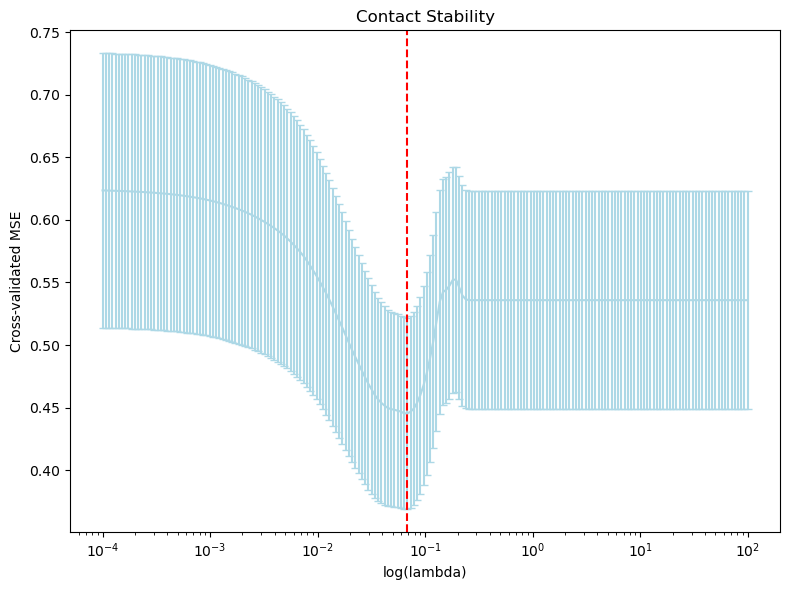

In [90]:
##make the plot to visualize the the lambda correponding to the lowest MSE

#set the canvas
fig, ax=plt.subplots(figsize=(8,6))

#specify the basic for x-axis, y-axis and how to calculate the error bars
ax.errorbar(lasso_cv.alphas_, MSE_mean_byLambda,
           yerr=MSE_std_byLambda/np.sqrt(62),
           color="lightblue", ecolor="lightblue",
           elinewidth=1.5, capsize=3)

#mark the best lambda
ax.axvline(lasso_cv.alpha_, color="red", linestyle="--")

##set the x-axis in log scale
ax.set_xscale('log')

##add label to make the plot more clear
ax.set_xlabel('log(lambda)')
ax.set_ylabel('Cross-validated MSE')
ax.set_title('Contact Stability')

plt.tight_layout()
plt.show()

In [91]:
print("Best lambda:", lasso_cv.alpha_)

Best lambda: 0.06826071834272393


## Step 2: fit the lasso regression with the best lambda

In [92]:
##fit the lasso regression
lasso_best=Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X, Y)

Lasso(alpha=np.float64(0.06826071834272393), max_iter=10000)

In [93]:
##Extract coefficient 
ContactStability_coef_df=pd.DataFrame(
    {'variables': continuous_vars+dummy,
    'Coefficient': lasso_best.coef_}
)

In [94]:
print(ContactStability_coef_df)

                               variables  Coefficient
0                          SCIBI_ASSCONT     0.097651
1                           SCIBI_FRIEND     0.148994
2                           SCIBI_NEGBEH     0.000000
3                          SCIBI_SUPPSEE     0.000000
4                           D_QEL_EmoCOn     0.000000
5                          D.QEL_SurfACt    -0.000000
6                          D.QEL_DeepAct     0.000000
7                          D.QEL_SurfHid     0.000000
8       COMMIT_SelfEff_BuildingCloseness     0.000000
9   COMMIT_SelfEff_ReflectiveFunctioning     0.000000
10                         COLLSUP_Total    -0.000000
11                         SUPSUPP_Total     0.000000
12                        WORKLOAD_Total    -0.128969
13            Staff_WorkExperience_Years    -0.000000
14                 Ratio_ClientsPerStaff    -0.000000
15               Client_LevelComm_Level2    -0.000000
16               Client_LevelComm_Level3     0.255380
17                Client_Lev

## Step 3.1: Use bootstrapping to do robustness check

In [97]:
n_bootstraps = 1000  
selection_counts = np.zeros(len(continuous_vars + dummy))

# Run bootstrap
for i in range(n_bootstraps):
    # Resample the data with replacement
    X_boot, Y_boot = resample(X, Y, random_state=i)
    
    # Fit LASSO with the best lambda found earlier
    lasso_boot = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    lasso_boot.fit(X_boot, Y_boot)
    
    # Count how many times each predictor has a non-zero coefficient
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# Calculate selection frequency as a percentage
selection_freq = selection_counts / n_bootstraps * 100

# Create results dataframe
ContactStability_bootstrap_df = pd.DataFrame({
    'Variable': continuous_vars + dummy,
    'Selection_Frequency(%)': selection_freq
})


In [98]:
print(ContactStability_bootstrap_df)

                                Variable  Selection_Frequency(%)
0                          SCIBI_ASSCONT                    78.5
1                           SCIBI_FRIEND                    90.6
2                           SCIBI_NEGBEH                    24.5
3                          SCIBI_SUPPSEE                    37.6
4                           D_QEL_EmoCOn                    29.7
5                          D.QEL_SurfACt                    24.9
6                          D.QEL_DeepAct                    30.4
7                          D.QEL_SurfHid                    17.1
8       COMMIT_SelfEff_BuildingCloseness                    24.2
9   COMMIT_SelfEff_ReflectiveFunctioning                    37.1
10                         COLLSUP_Total                    25.8
11                         SUPSUPP_Total                    29.3
12                        WORKLOAD_Total                    94.0
13            Staff_WorkExperience_Years                    36.7
14                 Ratio_

## Step 3.2: Covariate Test

In [99]:
import rpy2.robjects as ro
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [100]:
##extract what we need for R:
best_lambda = lasso_cv.alpha_
lasso_coef = lasso_best.coef_ 

In [101]:
##input to R:
%R -i X -i Y -i best_lambda -i lasso_coef

In [102]:
%%R

# Install if needed
if (!require("selectiveInference", quietly=TRUE)) {
    install.packages("selectiveInference", repos="https://cran.r-project.org")
}
library(selectiveInference)

# Convert to R matrix/vector format
X_r <- as.matrix(X)
Y_r <- as.vector(Y)
beta_r <- as.vector(lasso_coef)

# Step 4a: Estimate sigma
lasso.sigma <- estimateSigma(X_r, Y_r, intercept=FALSE, standardize=FALSE)
cat("Sigma estimate:", lasso.sigma$sigmahat, "\n")

# Step 4b: Run fixedLassoInf
lasso.inference <- fixedLassoInf(
    X_r, Y_r,
    beta_r,
    best_lambda,
    sigma = lasso.sigma$sigmahat,
    intercept = FALSE
)

print(lasso.inference)

Sigma estimate: 0.6481953 

Call:
fixedLassoInf(x = X_r, y = Y_r, beta = beta_r, lambda = best_lambda, 
    intercept = FALSE, sigma = lasso.sigma$sigmahat)

Standard deviation of noise (specified or estimated) sigma = 0.648

Testing results at lambda = 0.068, with alpha = 0.100

 Var   Coef Z-score P-value LowConfPt UpConfPt LowTailArea UpTailArea
   1  0.186   2.198   0.028     0.027    0.325       0.048      0.050
   2  0.238   2.803   0.005     0.091    0.379       0.049      0.049
  13 -0.208  -2.500   0.013    -0.346   -0.060       0.049      0.050
  17  0.273   2.113   0.035     0.028    0.487       0.050      0.049

Note: coefficients shown are partial regression coefficients


In addition: Warning message:
In fixedLassoInf(X_r, Y_r, beta_r, best_lambda, sigma = lasso.sigma$sigmahat,  :
  Solution beta does not satisfy the KKT conditions (to within specified tolerances)
